In [1]:
instala_bibliotecas = False
treinamento_completo = True # Se for False, ignora PyGAD e tenta carregar o arquivo .keras

busca_hiperparametros = False # Se True, executa PyGAD. Se False, pula PyGAD e usa os valores pré-definidos abaixo.
usa_cidade_estado = False # Controla se as colunas City e State serão incluídas no treino

#
best_emb_dim = 32
best_dense_units = 32
best_dropout_rate = 0.1
best_learning_rate = 0.1

minimo_reviews = 12  # Mínimo de reviews por usuário para entrar no dataset
minimo_reviews_livro = 4  # Mínimo de reviews por livro para ser recomendado (evita cold start)
idade_maxima = 100

# Filtro de qualidade da interação (Deletamos o antigo desconsidera_reviews_zerados)
considerar_apenas_positivos = True
nota_minima_positiva = 6

# Parâmetros de Busca de Hiperparâmetros (PyGAD) e Treinamento
num_geracoes_pygad = 3
num_individuos_pop = 4 # Tamanho da população inicial por geração
epocas_busca = 5
epocas_treino_final = 20

In [2]:
if instala_bibliotecas:
    # Instala dependencias
    !pip install scikit-learn
    !pip install pandas
    !pip install numpy
    !pip install matplotlib
    !pip install scipy
    !pip install kagglehub
    !pip install "tensorflow[and-cuda]"
    !pip install tensorflow-recommenders
    !pip install pygad
    !pip install tensorboard

In [3]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.model_selection import train_test_split
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
import tensorflow as tf
import tensorflow_recommenders as tfrs

c:\Src\NeoLeitura\.venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.1.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
c:\Src\NeoLeitura\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Download do dataset
path = kagglehub.dataset_download("arashnic/book-recommendation-dataset")
print("Caminho do dataset:", path)

Caminho do dataset: C:\Users\noise\.cache\kagglehub\datasets\arashnic\book-recommendation-dataset\versions\3


In [5]:
df_books = pd.read_csv(os.path.join(path, 'Books.csv'), encoding='utf-8')
df_ratings = pd.read_csv(os.path.join(path, 'Ratings.csv'))
df_users = pd.read_csv(os.path.join(path, 'Users.csv'))

C:\Users\noise\AppData\Local\Temp\ipykernel_29624\3570738106.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df_books = pd.read_csv(os.path.join(path, 'Books.csv'), encoding='utf-8')


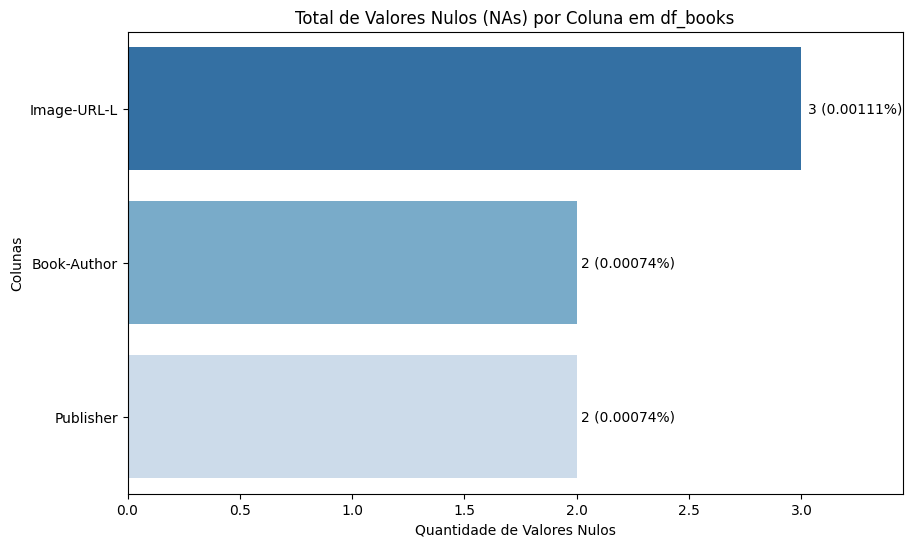

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calcular o total de nulos por coluna
missing_counts = df_books.isna().sum()

# Opcional: Filtrar apenas as colunas que realmente possuem valores nulos e ordenar
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

# 2. Calcular o tamanho do dataframe para a porcentagem
total_rows = len(df_books)

# 3. Criar a figura do gráfico
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=missing_counts.values, y=missing_counts.index, hue=missing_counts.index, palette="Blues_r", legend=False)

# 4. Adicionar os rótulos com a contagem e o percentual
for i, count in enumerate(missing_counts.values):
    # Calcula o percentual para essa coluna
    pct = (count / total_rows) * 100
    
    # Adiciona o texto: Ex: "150 (5.2%)"
    # O '+ (count * 0.01)' serve para afastar o texto levemente da ponta da barra
    ax.text(count + (count * 0.01), i, f'{count} ({pct:.5f}%)', va='center')

# 5. Ajustes finais de títulos e labels
plt.title('Total de Valores Nulos (NAs) por Coluna em df_books')
plt.xlabel('Quantidade de Valores Nulos')
plt.ylabel('Colunas')

# Ajusta o limite do eixo X para que os textos não sejam cortados
plt.xlim(0, missing_counts.max() * 1.15) 

plt.show()

In [7]:
# transformações do data set de livros

def transformation_books(df):
    df["Book-Title"] = df["Book-Title"].str.lower().str.strip()
    df["Book-Author"] = df["Book-Author"].str.lower().str.strip()
    df["Book-Author"] = df["Book-Author"].str.lower().str.strip()

    
    df["Year-Of-Publication"] = pd.to_numeric(df["Year-Of-Publication"], errors='coerce')

    invalid_mask = df["Year-Of-Publication"].isna() | (df["Year-Of-Publication"] == 0)
    
    print(f'Total de livros no dataset: {len(df)}')
    print(f'Número de livros com ano inválido: {invalid_mask.sum()}')

    # Criar subset apenas com anos válidos para busca mais rápida
    df_valid = df[~invalid_mask].copy()
    
    # Pré-calcular: ano mínimo por título + autor (Regra 1)
    year_by_title_author = df_valid.groupby(['Book-Title', 'Book-Author'])['Year-Of-Publication'].min().reset_index()
    year_by_title_author.rename(columns={'Year-Of-Publication': 'year_from_title'}, inplace=True)
    
    # Pré-calcular: ano médio por autor (Regra 2)
    year_by_author = df_valid.groupby('Book-Author')['Year-Of-Publication'].mean().reset_index()
    year_by_author.rename(columns={'Year-Of-Publication': 'year_from_author'}, inplace=True)
    
    # Fazer merge para preencher valores ausentes
    df = df.merge(year_by_title_author, on=['Book-Title', 'Book-Author'], how='left')
    df = df.merge(year_by_author, on='Book-Author', how='left')
    
    # Aplicar regras em cascata (vetorizado, sem loop!)
    # Regra 1: usar year_from_title quando disponível
    df.loc[invalid_mask & df['year_from_title'].notna(), 'Year-Of-Publication'] = df.loc[invalid_mask & df['year_from_title'].notna(), 'year_from_title']
    
    # Regra 2: usar year_from_author quando regra 1 não encontrou (year_from_title é NaN)
    df.loc[invalid_mask & df['year_from_title'].isna() & df['year_from_author'].notna(), 'Year-Of-Publication'] = df.loc[invalid_mask & df['year_from_title'].isna() & df['year_from_author'].notna(), 'year_from_author']
    
    # Regra 3: Preencher restante com 0 (quando nenhuma das regras anteriores funcionou)
    df.loc[invalid_mask & df['year_from_title'].isna() & df['year_from_author'].isna(), 'Year-Of-Publication'] = 0
    
    # Remover colunas auxiliares e converter para inteiro
    df.drop(columns=['year_from_title', 'year_from_author'], inplace=True)
    df["Year-Of-Publication"] = df["Year-Of-Publication"].astype(int)
    
    return df

def transformation_users(df):
    # Limpar Location: remover caracteres de pontuação indesejados (mantém apenas , / - e letras/números/espaços)
    df["Location"] = df["Location"].str.replace(r'["\|\\:;.!?(){}\[\]<>@#$%^&*+=~`\']', '', regex=True)
    df["Location"] = df["Location"].str.lower().str.strip()

    df.loc[df["Age"] > idade_maxima, "Age"] = idade_maxima #Alguns casos com pessoas com mais de 200 anos 
    
    # Separar Location em City, State, Country (da direita para esquerda)
    # rsplit com n=2 divide em no máximo 3 partes, começando pela direita
    location_split = df["Location"].str.rsplit(',', expand=True, n=2)    

    df["City"] = location_split[0].str.strip()
    df["State"] = location_split[1].str.strip()
    df["Country"] = location_split[2].str.strip()

    
    # Limpar strings vazias e transformar em None
    df["City"] = df["City"].replace('', None)
    df["State"] = df["State"].replace('', None)
    df["Country"] = df["Country"].replace('', None)
    
    # Estratégia vetorizada: criar lookups apenas dos registros completos
    df_completos = df[df["City"].notna() & df["State"].notna() & df["Country"].notna()].copy()
    
    if len(df_completos) > 0:
        # 1. Preencher Country baseado em City + State
        country_lookup = df_completos.groupby(['City', 'State'])['Country'].agg(
            lambda x: x.mode()[0] if len(x.mode()) > 0 else None
        ).reset_index()
        country_lookup.columns = ['City', 'State', 'Country_fill']
        
        df = df.merge(country_lookup, on=['City', 'State'], how='left', suffixes=('', '_lookup'))
        df.loc[df['Country'].isna() & df['Country_fill'].notna(), 'Country'] = df['Country_fill']
        df.drop(columns=['Country_fill'], inplace=True, errors='ignore')
        
        # 2. Preencher State baseado em City
        state_lookup = df_completos.groupby('City')['State'].agg(
            lambda x: x.mode()[0] if len(x.mode()) > 0 else None
        ).reset_index()
        state_lookup.columns = ['City', 'State_fill']
        
        df = df.merge(state_lookup, on='City', how='left', suffixes=('', '_lookup'))
        df.loc[df['State'].isna() & df['State_fill'].notna(), 'State'] = df['State_fill']
        df.drop(columns=['State_fill'], inplace=True, errors='ignore')
        
        # 3. Segunda passada: preencher Country novamente após atualizar State
        df = df.merge(country_lookup, on=['City', 'State'], how='left', suffixes=('', '_lookup2'))
        df.loc[df['Country'].isna() & df['Country_fill'].notna(), 'Country'] = df['Country_fill']
        df.drop(columns=['Country_fill'], inplace=True, errors='ignore')

    # Preencher Age com estratégia vetorizada: mediana por Country, fallback para mediana global
    mediana_global = df["Age"].median()
    
    # Calcular mediana de idade por país (apenas registros com Age válido)
    df_age_valid = df[df["Age"].notna()].copy()
    if len(df_age_valid) > 0 and df["Country"].notna().any():
        age_by_country = df_age_valid.groupby('Country')['Age'].median().reset_index()
        age_by_country.columns = ['Country', 'Age_median']
        
        # Merge para preencher com mediana por país
        df = df.merge(age_by_country, on='Country', how='left', suffixes=('', '_lookup'))
        df.loc[df['Age'].isna() & df['Age_median'].notna(), 'Age'] = df['Age_median']
        df.drop(columns=['Age_median'], inplace=True, errors='ignore')
    
    # Preencher os que sobraram com mediana global
    df["Age"] = df["Age"].fillna(mediana_global)

    return df

df_books = transformation_books(df_books)
df_users = transformation_users(df_users)

Total de livros no dataset: 271360
Número de livros com ano inválido: 4621


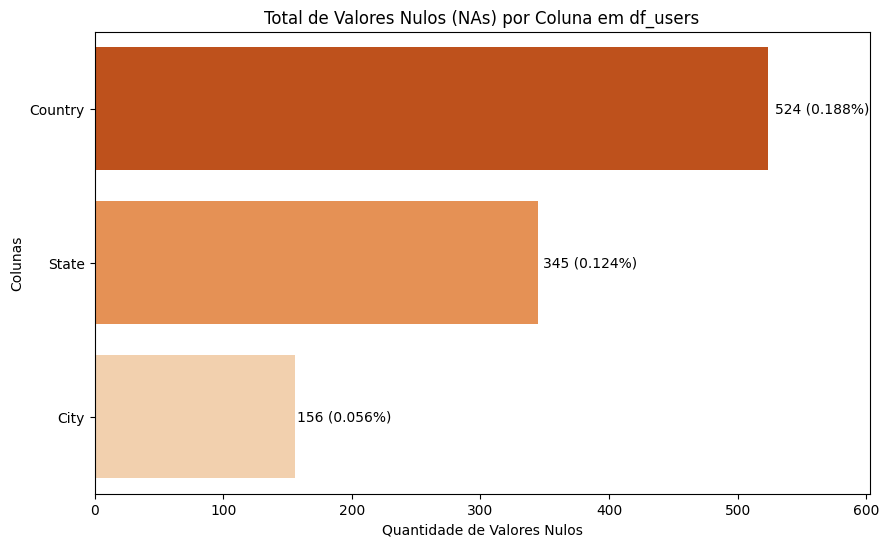

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calcular o total de nulos por coluna
missing_counts_users = df_users.isna().sum()

# Opcional: Filtrar apenas as colunas que realmente possuem valores nulos e ordenar
missing_counts_users = missing_counts_users[missing_counts_users > 0].sort_values(ascending=False)

# 2. Calcular o tamanho do dataframe para a porcentagem
total_rows_users = len(df_users)

# Se não houver nulos, mostramos uma mensagem, senão plotamos
if len(missing_counts_users) > 0:
    # 3. Criar a figura do gráfico
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(x=missing_counts_users.values, y=missing_counts_users.index, hue=missing_counts_users.index, palette="Oranges_r", legend=False)

    # 4. Adicionar os rótulos com a contagem e o percentual
    for i, count in enumerate(missing_counts_users.values):
        # Calcula o percentual para essa coluna
        pct = (count / total_rows_users) * 100
        
        # Adiciona o texto com a contagem e %
        ax.text(count + (count * 0.01), i, f'{count} ({pct:.3f}%)', va='center')

    # 5. Ajustes finais de títulos e labels
    plt.title('Total de Valores Nulos (NAs) por Coluna em df_users')
    plt.xlabel('Quantidade de Valores Nulos')
    plt.ylabel('Colunas')

    # Ajusta o limite do eixo X para que os textos não sejam cortados
    plt.xlim(0, missing_counts_users.max() * 1.15) 

    plt.show()
else:
    print("O dataframe df_users não possui valores nulos em nenhuma coluna.")

In [9]:
# Adicionando reviews pessoais para validação de recomendações
df_users.loc[len(df_users)] = {
    'User-ID': 999999,
    'Location': 'curitiba, parana, brazil',
    'Age': 36,
    'City': 'curitiba',
    'State': 'parana',
    'Country': 'brazil'
}

# 1984, meu favorito
df_ratings.loc[len(df_ratings)] = {
    'User-ID': 999999,
    'ISBN': '0451524934',
    'Book-Rating': 10
}

# Cidade de deus
df_ratings.loc[len(df_ratings)] = {
    'User-ID': 999999,
    'ISBN': '8483102358',
    'Book-Rating': 9
}

# Crime e castigo
df_ratings.loc[len(df_ratings)] = {
    'User-ID': 999999,
    'ISBN': '2877142639',
    'Book-Rating': 9
}

# o estrangeiro
df_ratings.loc[len(df_ratings)] = {
    'User-ID': 999999,
    'ISBN': '0679720200',
    'Book-Rating': 8
}

# 100 anos de solidão
df_ratings.loc[len(df_ratings)] = {
    'User-ID': 999999,
    'ISBN': '0060929790',
    'Book-Rating': 10
}

## alguns que não gostei tanto:
df_ratings.loc[len(df_ratings)] = {
    'User-ID': 999999,
    'ISBN': '043938950X',
    'Book-Rating': 4
}


df_ratings.loc[len(df_ratings)] = {
    'User-ID': 999999,
    'ISBN': '0446697524',
    'Book-Rating': 1
}

df_ratings.loc[len(df_ratings)] = {
    'User-ID': 999999,
    'ISBN': '1577311523',
    'Book-Rating': 3
}

df_ratings.loc[len(df_ratings)] = {
    'User-ID': 999999,
    'ISBN': '0671733354',
    'Book-Rating': 1
}

# Olga Tokarczuk -  House of Day, House of Night (Writings from an Unbound Europe (Paperback)) House of Day, House of Night (Writings from an Unbound Europe (Paperback)) 
df_ratings.loc[len(df_ratings)] = {
    'User-ID': 999999,
    'ISBN': '0810118920',
    'Book-Rating': 8,
}

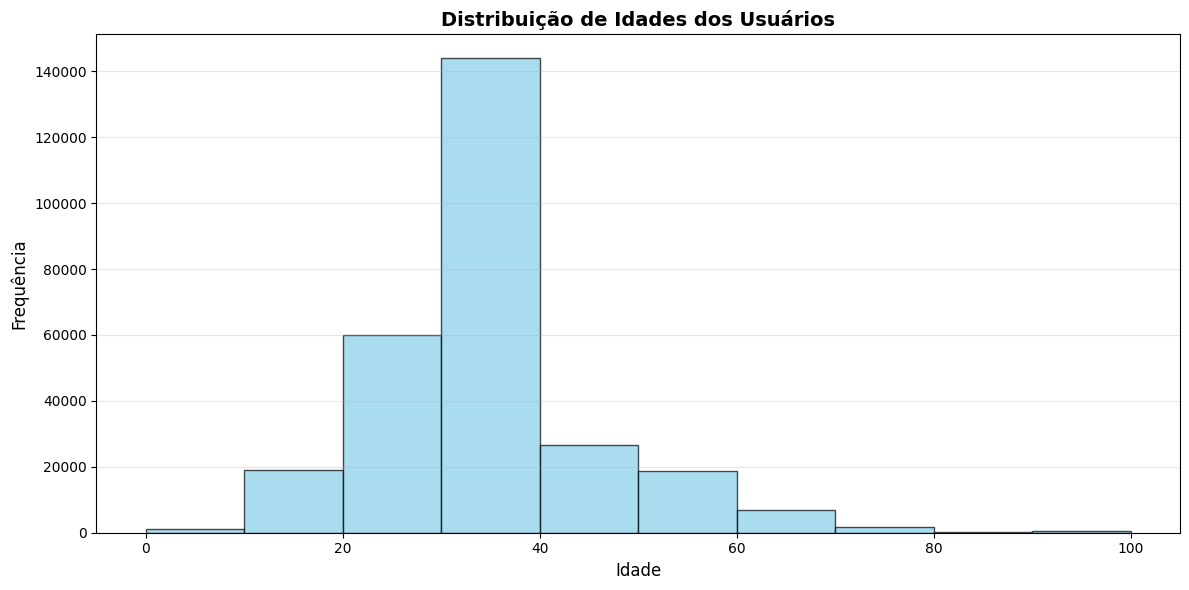

Número total de usuários: 278859
usuários com reviews: 105284


In [10]:
# Análise da distribuição de idades dos usuários

plt.figure(figsize=(12, 6))
plt.hist(df_users['Age'], bins=range(0, int(df_users['Age'].max()) + 10, 10), 
         edgecolor='black', color='skyblue', alpha=0.7)
plt.xlabel('Idade', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.title('Distribuição de Idades dos Usuários', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

df_users['Age'].describe()

print(f'Número total de usuários: {len(df_users)}')
print(f'usuários com reviews: {(df_users["User-ID"].isin(df_ratings["User-ID"].unique())).sum()}')

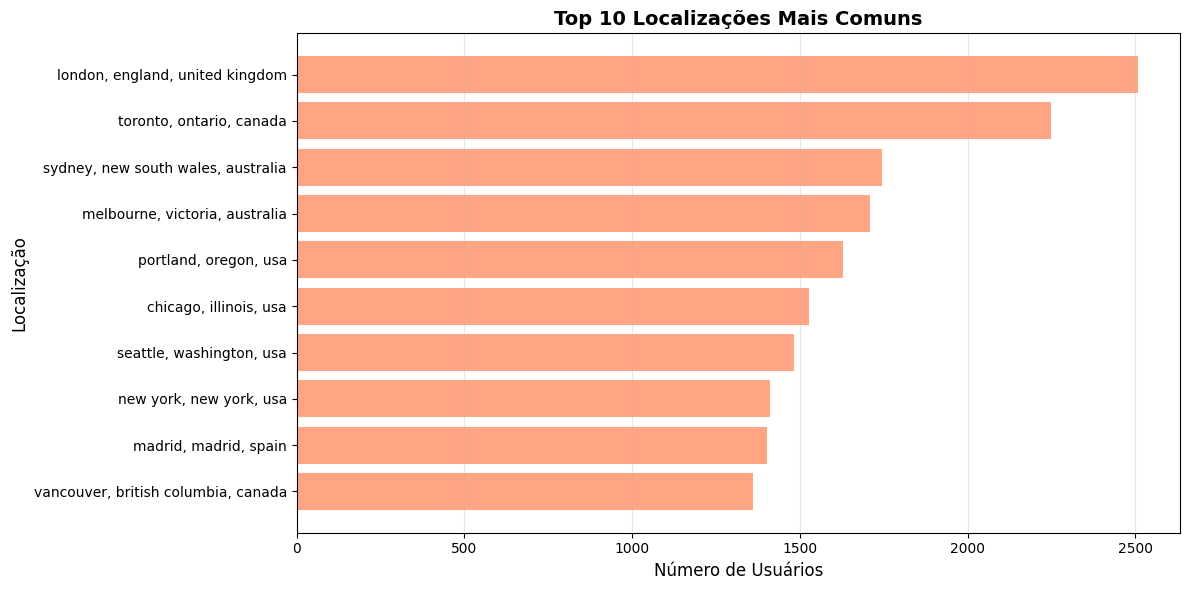

In [11]:
# Análise das 10 localizações mais comuns

top_10_locations = df_users['Location'].value_counts().head(10)

plt.figure(figsize=(12, 6))
plt.barh(range(len(top_10_locations)), top_10_locations.values, color='coral', alpha=0.7)
plt.yticks(range(len(top_10_locations)), top_10_locations.index)
plt.xlabel('Número de Usuários', fontsize=12)
plt.ylabel('Localização', fontsize=12)
plt.title('Top 10 Localizações Mais Comuns', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()  # localização mais comum no topo
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


Total de ratings com nota 0: 716,109
Percentual: 62.28%
Total geral de avaliações: 1,149,790



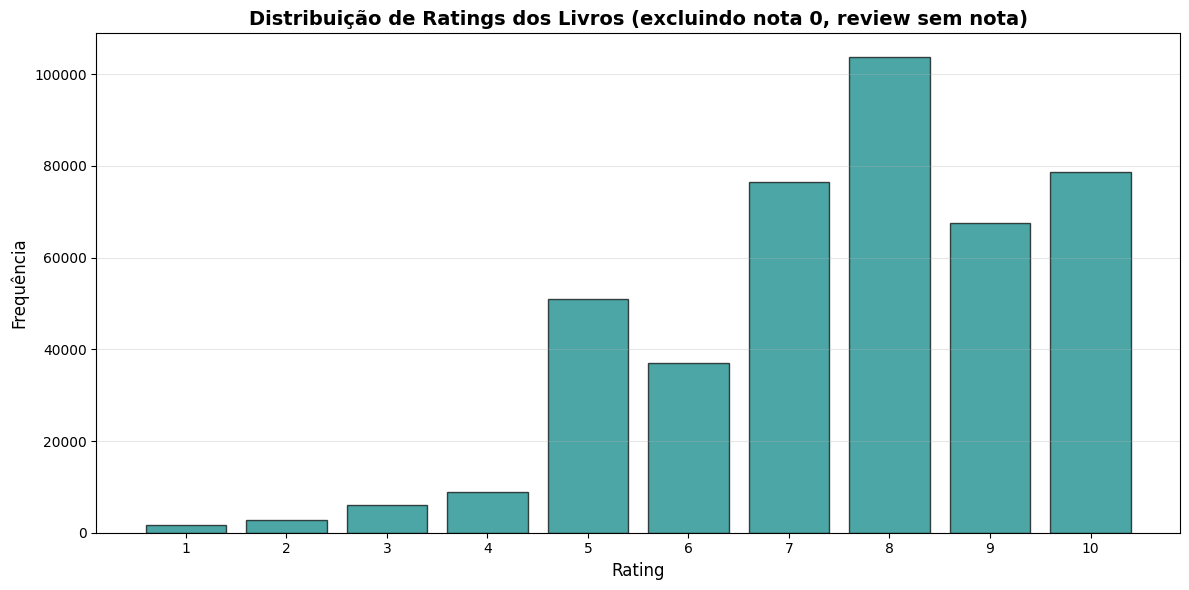

In [12]:
# Análise da distribuição de ratings

rating_counts = df_ratings['Book-Rating'].value_counts().sort_index()

total_ratings = len(df_ratings)
ratings_zerados = rating_counts.get(0, 0)
percentual_zero = (ratings_zerados / total_ratings) * 100

print(f"Total de ratings com nota 0: {ratings_zerados:,}")
print(f"Percentual: {percentual_zero:.2f}%")
print(f"Total geral de avaliações: {total_ratings:,}\n")

# Gráfico sem considerar nota 0
rating_counts_sem_zero = rating_counts[rating_counts.index != 0]

plt.figure(figsize=(12, 6))
plt.bar(rating_counts_sem_zero.index, rating_counts_sem_zero.values, color='teal', alpha=0.7, edgecolor='black')
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.title('Distribuição de Ratings dos Livros (excluindo nota 0, review sem nota)', fontsize=14, fontweight='bold')
plt.xticks(range(1, 11))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [13]:
# unificação dos datasets para recomendação
df_user_ranting = df_users.merge(df_ratings, on="User-ID", how="inner")
df_desnormalizado = df_user_ranting.merge(df_books, on="ISBN", how="inner")
df_desnormalizado = df_desnormalizado.drop(columns=['Image-URL-S', 'Image-URL-M', 'Image-URL-L', 'Location'])
df_desnormalizado = df_desnormalizado.dropna()

In [14]:
## análise exploratória e filtros para manter apenas usuários com registros suficientes para avaliação de recomendações
print(f"Dimensão do dataframe desnormalizado: {df_desnormalizado.shape}")

df_desnormalizado_filtered = df_desnormalizado.copy()

if considerar_apenas_positivos:
    # Mantém interação implícita pura (0) OR interação explícita positiva (>= nota_minima_positiva)
    # Remove as interações que sabemos explicitamente que foram ruins (1 a 5)
    mask_positiva = (df_desnormalizado_filtered["Book-Rating"] == 0) | (df_desnormalizado_filtered["Book-Rating"] >= nota_minima_positiva)
    df_desnormalizado_filtered = df_desnormalizado_filtered[mask_positiva]

livros_minimo_reviews = df_desnormalizado_filtered["ISBN"].value_counts()
print(f'Total de livros: {len(livros_minimo_reviews)}')
print(f'Número de livros com pelo menos {minimo_reviews_livro} avaliações: {len(livros_minimo_reviews[livros_minimo_reviews >= minimo_reviews_livro])}')

livros_filtrados = livros_minimo_reviews[livros_minimo_reviews >= minimo_reviews_livro].index

df_desnormalizado_filtered = df_desnormalizado_filtered[df_desnormalizado_filtered["ISBN"].isin(livros_filtrados)].copy()

reviews_users = df_desnormalizado_filtered["User-ID"].value_counts()

print(f'Total de usuários: {len(reviews_users)}')
print(f'Número de usuários com pelo menos {minimo_reviews} avaliações: {len(reviews_users[reviews_users >= minimo_reviews])}')

usuarios_filtrados = reviews_users[reviews_users >= minimo_reviews].index

df_desnormalizado_filtered = df_desnormalizado_filtered[df_desnormalizado_filtered["User-ID"].isin(usuarios_filtrados)].copy()

print(f"Dimensão do dataframe filtrado: {df_desnormalizado_filtered.shape}")

Dimensão do dataframe desnormalizado: (1029342, 11)
Total de livros: 257683
Número de livros com pelo menos 4 avaliações: 50523
Total de usuários: 72418
Número de usuários com pelo menos 12 avaliações: 7143
Dimensão do dataframe filtrado: (530365, 11)


In [15]:
# Separando dados de treino x teste (75/25)
df_train, df_test = train_test_split(
    df_desnormalizado_filtered, 
    test_size=0.25,
    random_state=42,
    stratify=df_desnormalizado_filtered['User-ID']  # Garante mesma proporção de usuários
)

In [16]:
# Treinamento Modelo
import pygad

def to_str_arr(series): return np.array(series.fillna("unknown").astype(str), dtype=object)
def to_float_arr(series): return np.array(series.fillna(0), dtype=np.float32)

def create_tf_dict(df):
    d = {
        "user_id": to_str_arr(df['User-ID']),
        "age": to_float_arr(df['Age']),
        "country": to_str_arr(df['Country']),
        "isbn": to_str_arr(df['ISBN']),
        "title": to_str_arr(df['Book-Title']),
        "author": to_str_arr(df['Book-Author']),
        "year": to_float_arr(df['Year-Of-Publication']),
        "publisher": to_str_arr(df['Publisher'])
    }
    if usa_cidade_estado:
        d["city"] = to_str_arr(df['City'])
        d["state"] = to_str_arr(df['State'])
    return d

train_ds = tf.data.Dataset.from_tensor_slices(create_tf_dict(df_train)).batch(2048).cache()
test_ds = tf.data.Dataset.from_tensor_slices(create_tf_dict(df_test)).batch(2048).cache()

# Títulos únicos para candidatos
df_books_unique = df_desnormalizado_filtered.drop_duplicates(subset=['ISBN'])
books_ds = tf.data.Dataset.from_tensor_slices({
    "isbn": to_str_arr(df_books_unique['ISBN']),
    "title": to_str_arr(df_books_unique['Book-Title']),
    "author": to_str_arr(df_books_unique['Book-Author']),
    "year": to_float_arr(df_books_unique['Year-Of-Publication']),
    "publisher": to_str_arr(df_books_unique['Publisher'])
}).batch(1024).cache()

# Vocabulários Únicos (Processamento Otimizado)
vocab_user_id = np.unique(to_str_arr(df_desnormalizado_filtered['User-ID']))
vocab_country = np.unique(to_str_arr(df_desnormalizado_filtered['Country']))
if usa_cidade_estado:
    vocab_city = np.unique(to_str_arr(df_desnormalizado_filtered['City']))
    vocab_state = np.unique(to_str_arr(df_desnormalizado_filtered['State']))

vocab_isbn = np.unique(to_str_arr(df_desnormalizado_filtered['ISBN']))
vocab_author = np.unique(to_str_arr(df_desnormalizado_filtered['Book-Author']))
vocab_publisher = np.unique(to_str_arr(df_desnormalizado_filtered['Publisher']))


# --- CONSTRUÇÃO DA TORRE DO USUÁRIO ---
class UserModel(tf.keras.Model):
    def __init__(self, emb_dim=32, dense_units=64, dropout_rate=0.2):
        super().__init__()
        self.user_emb = tf.keras.Sequential([
            tf.keras.layers.StringLookup(vocabulary=vocab_user_id, mask_token=None),
            tf.keras.layers.Embedding(len(vocab_user_id) + 1, emb_dim)
        ])
        
        # Para variáveis mais genéricas, usamos um emb_dim menor, mas limitado a no mínimo 8
        geo_dim = max(8, emb_dim // 4)
        
        if usa_cidade_estado:
            self.city_emb = tf.keras.Sequential([
                tf.keras.layers.StringLookup(vocabulary=vocab_city, mask_token=None),
                tf.keras.layers.Embedding(len(vocab_city) + 1, geo_dim)
            ])
            self.state_emb = tf.keras.Sequential([
                tf.keras.layers.StringLookup(vocabulary=vocab_state, mask_token=None),
                tf.keras.layers.Embedding(len(vocab_state) + 1, geo_dim)
            ])
            
        self.country_emb = tf.keras.Sequential([
            tf.keras.layers.StringLookup(vocabulary=vocab_country, mask_token=None),
            tf.keras.layers.Embedding(len(vocab_country) + 1, geo_dim)
        ])
        
        self.age_norm = tf.keras.layers.Normalization(axis=None)
        self.age_norm.adapt(to_float_arr(df_desnormalizado_filtered['Age']))

        self.dense = tf.keras.Sequential([
            tf.keras.layers.Dense(dense_units, activation="relu"),
            tf.keras.layers.Dropout(dropout_rate),
            tf.keras.layers.Dense(dense_units // 2)
        ])

    def call(self, inputs, training=False):
        features = [
            self.user_emb(inputs["user_id"]),
            self.country_emb(inputs["country"]),
            tf.reshape(self.age_norm(inputs["age"]), (-1, 1))
        ]
        if usa_cidade_estado:
            features.append(self.city_emb(inputs["city"]))
            features.append(self.state_emb(inputs["state"]))
            
        x = tf.concat(features, axis=1)
        return self.dense(x, training=training)

# --- CONSTRUÇÃO DA TORRE DO LIVRO ---
class BookModel(tf.keras.Model):
    def __init__(self, emb_dim=32, dense_units=64, dropout_rate=0.2):
        super().__init__()
        self.isbn_emb = tf.keras.Sequential([
            tf.keras.layers.StringLookup(vocabulary=vocab_isbn, mask_token=None),
            tf.keras.layers.Embedding(len(vocab_isbn) + 1, emb_dim)
        ])
        
        meta_dim = max(16, emb_dim // 2)
        
        self.author_emb = tf.keras.Sequential([
            tf.keras.layers.StringLookup(vocabulary=vocab_author, mask_token=None),
            tf.keras.layers.Embedding(len(vocab_author) + 1, meta_dim)
        ])
        self.publisher_emb = tf.keras.Sequential([
            tf.keras.layers.StringLookup(vocabulary=vocab_publisher, mask_token=None),
            tf.keras.layers.Embedding(len(vocab_publisher) + 1, meta_dim)
        ])
        
        self.title_vectorizer = tf.keras.layers.TextVectorization(max_tokens=10000)
        self.title_vectorizer.adapt(to_str_arr(df_desnormalizado_filtered['Book-Title']))
        
        self.title_emb = tf.keras.Sequential([
            self.title_vectorizer,
            tf.keras.layers.Embedding(10000, emb_dim, mask_zero=False),
            tf.keras.layers.GlobalAveragePooling1D()
        ])

        self.year_norm = tf.keras.layers.Normalization(axis=None)
        self.year_norm.adapt(to_float_arr(df_desnormalizado_filtered['Year-Of-Publication']))

        self.dense = tf.keras.Sequential([
            tf.keras.layers.Dense(dense_units, activation="relu"),
            tf.keras.layers.Dropout(dropout_rate),
            tf.keras.layers.Dense(dense_units // 2)
        ])

    def call(self, inputs, training=False):
        x = tf.concat([
            self.isbn_emb(inputs["isbn"]),
            self.author_emb(inputs["author"]),
            self.publisher_emb(inputs["publisher"]),
            self.title_emb(inputs["title"]),
            tf.reshape(self.year_norm(inputs["year"]), (-1, 1))
        ], axis=1)
        return self.dense(x, training=training)

# --- ACOPLAMENTO METRICAS E LOSS ---
class BookRecommenderModel(tfrs.Model):
    def __init__(self, user_model, item_model):
        super().__init__()
        self.user_model = user_model
        self.item_model = item_model
        self.task = tfrs.tasks.Retrieval(metrics=tfrs.metrics.FactorizedTopK(candidates=books_ds.map(self.item_model)))

    def compute_loss(self, features, training=False):
        user_features_keys = ["user_id", "age", "country"]
        if usa_cidade_estado:
            user_features_keys.extend(["city", "state"])
            
        user_embeddings = self.user_model({k: features[k] for k in user_features_keys}, training=training)
        item_embeddings = self.item_model({k: features[k] for k in ["isbn", "title", "author", "year", "publisher"]}, training=training)
        return self.task(user_embeddings, item_embeddings, compute_metrics=not training)


# 3. BUILDER CONFIGURÁVEL
def build_model(emb_dim, dense_units, dropout_rate, lr):
    user_model = UserModel(emb_dim=emb_dim, dense_units=dense_units, dropout_rate=dropout_rate)
    book_model = BookModel(emb_dim=emb_dim, dense_units=dense_units, dropout_rate=dropout_rate)
    model = BookRecommenderModel(user_model, book_model)
    model.compile(optimizer=tf.keras.optimizers.Adagrad(learning_rate=lr))
    return model

MODEL_WEIGHTS_PATH = "models/tfrs_hybrid_best_weights.weights.h5"

if treinamento_completo:
    if busca_hiperparametros:
        print("Iniciando Busca com PyGAD")

        def fitness_func(ga_instance, solution, solution_idx):
            tf.keras.backend.clear_session() # Limpa memória para evitar OOM e vazamento de tensores
            
            _emb_dim = int(solution[0])
            _dense_units = int(solution[1])
            _dropout_rate = float(solution[2])
            _lr = float(solution[3])
            
            print(f"\n[PyGAD] Avaliando Indivíduo -> emb_dim={_emb_dim}, dense={_dense_units}, dropout={_dropout_rate:.1f}, lr={_lr}")
            
            model_trial = build_model(_emb_dim, _dense_units, _dropout_rate, _lr)
            
            # Callback de parada na busca caso não melhore (usando validação)
            early_stopping = tf.keras.callbacks.EarlyStopping(
                monitor="val_factorized_top_k/top_10_categorical_accuracy", 
                patience=2, # Patience curto para ser mais ágil
                mode="max"
            )
            
            history = model_trial.fit(
                train_ds, 
                validation_data=test_ds,
                epochs=epocas_busca, # Parametrizado
                callbacks=[early_stopping],
                verbose=1
            )
            
            metric_key = "val_factorized_top_k/top_10_categorical_accuracy"
            val_acc = max(history.history.get(metric_key, [0]))
                
            print(f"Accuracy Máxima Testada: {val_acc:.4f}\n")
            return val_acc

        # Definimos o espaço exato de possibilidades de cada gene (Hiperparâmetros)
        gene_space = [
            [16, 32, 64],           # Gene 0: emb_dim
            [32, 64, 128],          # Gene 1: dense_units
            [0.1, 0.2, 0.3, 0.4],   # Gene 2: dropout_rate
            [1e-1, 1e-2, 5e-3]      # Gene 3: learning_rate
        ]

        # Inicializamos o simulador Evolutivo
        ga_instance = pygad.GA(
            num_generations=num_geracoes_pygad,
            num_parents_mating=2,
            fitness_func=fitness_func,
            sol_per_pop=num_individuos_pop,
            num_genes=4,
            gene_space=gene_space,
            mutation_percent_genes=25,
            suppress_warnings=True
        )

        ga_instance.run()

        # Resgata o DNA vencedor global
        solution, solution_fitness, solution_idx = ga_instance.best_solution()

        best_hps = {
            'emb_dim': int(solution[0]),
            'dense_units': int(solution[1]),
            'dropout_rate': float(solution[2]),
            'learning_rate': float(solution[3])
        }

        print("\nMELHORES HIPERPARÂMETROS ENCONTRADOS")
        print(f"  - Embedding Dimension: {best_hps.get('emb_dim')}")
        print(f"  - Dense Units: {best_hps.get('dense_units')} -> {best_hps.get('dense_units') // 2}")
        print(f"  - Dropout Rate: {best_hps.get('dropout_rate'):.1f}")
        print(f"  - Learning Rate: {best_hps.get('learning_rate')}")
        print(f"  - Top 10 Accuracy (Fitness): {solution_fitness:.4f}")
        print("=========================================================\n")

        # Atualiza as variáveis globais com os melhores do tuning
        best_emb_dim = best_hps['emb_dim']
        best_dense_units = best_hps['dense_units']
        best_dropout_rate = best_hps['dropout_rate']
        best_learning_rate = best_hps['learning_rate']

    else:
        print("Utilizando hiperparâmetros fixos ")

    # 4. TREINANDO O MODELO FINAL COM OS PARÂMETROS CAMPEÕES
    tf.keras.backend.clear_session()
    model_tfrs = build_model(
        emb_dim=best_emb_dim,
        dense_units=best_dense_units,
        dropout_rate=best_dropout_rate,
        lr=best_learning_rate
    )

    # Realiza o early-stop caso o modelo perca performance e restaura o melhor resultado
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="val_factorized_top_k/top_10_categorical_accuracy", 
        patience=3, # Ajustado para 3
        mode="max",
        restore_best_weights=True
    )

    # Salva os pesos após treino com epochs extensos:
    model_tfrs.fit(
        train_ds, 
        validation_data=test_ds,
        epochs=epocas_treino_final,
        callbacks=[early_stopping]
    )
    
    os.makedirs("models", exist_ok=True)
    model_tfrs.save_weights(MODEL_WEIGHTS_PATH)
    print(f"Pesos do modelo salvos com sucesso em: {MODEL_WEIGHTS_PATH}")
    

else:
    print(f"\n⚡ Pulando otimização (PyGAD) e Treinamento! Recriando arquitetura e carregando pesos do arquivo: {MODEL_WEIGHTS_PATH}")
    
    try:
        # 1. Recriamos a arquitetura do modelo
        model_tfrs = build_model(
            emb_dim=best_emb_dim,
            dense_units=best_dense_units,
            dropout_rate=best_dropout_rate,
            lr=best_learning_rate
        )
        
        # 2. Inicializamos as variáveis de peso do modelo instanciado com um pequeno "fake" batch de dados
        # O TensorFlow precisa disso para as Custom Layers criarem a respectiva "shape" para aí sim absorver os pesos corretos
        dummy_batch = next(iter(train_ds.take(1)))
        model_tfrs(dummy_batch)
        
        # 3. Carregamos o arquivo H5
        model_tfrs.load_weights(MODEL_WEIGHTS_PATH)
        print("✅ Pesos carregados com sucesso e modelo inicializado!")
        
    except Exception as e:
        print(f"Erro Fatal ao carregar {MODEL_WEIGHTS_PATH}: {e}")

# 5. AVALIANDO
print("Avaliação do modelo final:")
test_metrics = model_tfrs.evaluate(test_ds, return_dict=True)
accuracy_top10 = test_metrics.get("factorized_top_k/top_10_categorical_accuracy", 0)
print(f"Top-10 Accuracy Teste Híbrido: {accuracy_top10:.4f}")

# ==========================================
# 6. SALVANDO RELATÓRIO DA AVALIAÇÃO EM ARQUIVO
# ==========================================
import datetime
import os

data_hora = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
report_content = f"""
======================================================
Data/Hora da Avaliação : {data_hora}
Top-10 Accuracy        : {accuracy_top10:.4f}

--- Hiperparâmetros Configurados e Utilizados ---
- usa_cidade_estado    : {usa_cidade_estado}
- best_emb_dim         : {best_emb_dim}
- best_dense_units     : {best_dense_units}
- best_dropout_rate    : {best_dropout_rate}
- best_learning_rate   : {best_learning_rate}
======================================================
"""

arquivo_relatorio = "historico_treinamentos.txt"
with open(arquivo_relatorio, "a", encoding="utf-8") as f:
    f.write(report_content)

print(f"\n✅ Relatório de desempenho consolidado com sucesso no arquivo '{arquivo_relatorio}'! (Adicionado ao fim do arquivo)")

Utilizando hiperparâmetros fixos 


Epoch 1/20
195/195 [==============================] - 60s 302ms/step - factorized_top_k/top_1_categorical_accuracy: 0.0000e+00 - factorized_top_k/top_5_categorical_accuracy: 0.0000e+00 - factorized_top_k/top_10_categorical_accuracy: 0.0000e+00 - factorized_top_k/top_50_categorical_accuracy: 0.0000e+00 - factorized_top_k/top_100_categorical_accuracy: 0.0000e+00 - loss: 14928.1342 - regularization_loss: 0.0000e+00 - total_loss: 14928.1342 - val_factorized_top_k/top_1_categorical_accuracy: 1.2067e-04 - val_factorized_top_k/top_5_categorical_accuracy: 8.2207e-04 - val_factorized_top_k/top_10_categorical_accuracy: 0.0016 - val_factorized_top_k/top_50_categorical_accuracy: 0.0078 - val_factorized_top_k/top_100_categorical_accuracy: 0.0151 - val_loss: 10416.2383 - val_regularization_loss: 0.0000e+00 - val_total_loss: 10416.2383
Epoch 2/20
195/195 [==============================] - 58s 296ms/step - factorized_top_k/top_1_categorical_accuracy: 0.0000e+00 - fa

In [17]:
# teste com usuário manual

user_id_test = "999999"

# Cria um indexador tensor super veloz na memória para o TFRS
index = tfrs.layers.factorized_top_k.BruteForce(model_tfrs.user_model)

# Note que o mapeamento dos livros agora espera nosso dicionário completo
index.index_from_dataset(
  books_ds.map(lambda x: (x["isbn"], model_tfrs.item_model(x)))
)

# Precisamos recuperar os metadados do usuário de teste para fazer a predição!
user_row = df_users[df_users['User-ID'] == int(user_id_test)].iloc[0]

# Preparamos o Tensor com todas as features do usuário, do mesmo jeito que a Torra do Usúario (UserModel) espera receber
user_input = {
    "user_id": tf.constant([user_id_test]),
    "age": tf.constant([np.float32(user_row['Age'])]),
    "country": tf.constant([str(user_row['Country'])])
}

if usa_cidade_estado:
    user_input["city"] = tf.constant([str(user_row['City'])])
    user_input["state"] = tf.constant([str(user_row['State'])])

# Infere todos contra o usuário alvo em O(1)
scores_tf, titles_tf = index(user_input)
recommended_isbns = [isbn.decode('utf-8') for isbn in titles_tf[0, :30].numpy()]

# Mantemos apenas os livros que ele nunca leu antes
seen_tf = set(df_train[df_train['User-ID'] == int(user_id_test)]['ISBN'].values)
recs_final = [i for i in recommended_isbns if i not in seen_tf][:10]

tf_recs_df = pd.DataFrame({'ISBN': recs_final})
tf_recs_full = tf_recs_df.merge(df_books[['ISBN', 'Book-Title', 'Book-Author', 'Year-Of-Publication']], on='ISBN', how='left')

print(f"🎯 Top 10 Recomendações TensorFlow HÍBRIDO para Usuário {user_id_test}:\n")
print("=" * 100)
print(tf_recs_full[['Book-Title', 'Book-Author', 'Year-Of-Publication']].to_string(index=False))
print("=" * 100)

# Visualizar Histórico do usuário alvo
user_history = df_ratings[df_ratings['User-ID'] == int(user_id_test)].merge(
    df_books[['ISBN', 'Book-Title', 'Book-Author']],
    on='ISBN',
    how='left'
).sort_values('Book-Rating', ascending=False)

print(f"\n📖 Histórico de Leituras do Usuário {user_id_test}:")
print("=" * 100)
print(user_history[['Book-Title', 'Book-Author', 'Book-Rating']].to_string(index=False))
print("=" * 100)

🎯 Top 10 Recomendações TensorFlow HÍBRIDO para Usuário 999999:

                                         Book-Title             Book-Author  Year-Of-Publication
                                 das boot: the boat lothar gunther buchheim                 2003
                     to the poles (without a beard)       catharine hartley                 2002
have i got news for you: the shameless cash-in book          jimmy mulville                 1994
                                          harm done            ruth rendell                 1993
                      lion time collected stories 6       robert silverberg                 1990
                            falling towards england             clive james                 1987
                                        bone people              keri hulme                 1989
                                 as it is in heaven          niall williams                 1999
                                                 45           b

In [18]:
# ==========================================
# TESTE DE COLD START (USUÁRIO FANTASMA)
# ==========================================
print("Simulando Cold Start: Novo Usuário sem histórico...")

# Um ID inexistente no vocabulário!
user_id_cold = "888888" 
user_age = 28
city = "barcelona"
state = "catalonia"
country = "spain"

# Vamos fingir que é um adolescente do Texas, EUA
user_input_cold = {
    "user_id": tf.constant([user_id_cold]),
    "age": tf.constant([np.float32(user_age)]),
    "country": tf.constant([country])
}

if usa_cidade_estado:
    user_input_cold["city"] = tf.constant([city])
    user_input_cold["state"] = tf.constant([state])

# Realiza a busca no Index TFRS (Não há histórico para isolar, então pegamos direto as 10)
scores_cold, titles_cold = index(user_input_cold)
recs_cold_isbns = [isbn.decode('utf-8') for isbn in titles_cold[0, :10].numpy()]

# Monta o DataFrame para leitura humana
df_recs_cold = pd.DataFrame({'ISBN': recs_cold_isbns})
df_recs_cold_full = df_recs_cold.merge(df_books[['ISBN', 'Book-Title', 'Book-Author', 'Year-Of-Publication']], on='ISBN', how='left')

print(f"🎯 Top 10 Recomendações (Cold Start) para Usuário {user_id_cold} ({user_age} anos, {city}, {state}, {country}):\n")
print("=" * 100)
print(df_recs_cold_full[['Book-Title', 'Book-Author', 'Year-Of-Publication']].to_string(index=False))
print("=" * 100)

Simulando Cold Start: Novo Usuário sem histórico...
🎯 Top 10 Recomendações (Cold Start) para Usuário 888888 (28 anos, barcelona, catalonia, spain):

                                                       Book-Title           Book-Author  Year-Of-Publication
                                  el ultimo encuentro (narrativa)          sandor marai                 2001
la insoportable levedad del ser/the unbearable lightness of being         milan kundera                 1993
                                                el mundo de sofia       jostein gaarder                 1994
                                             un calor tan cercano         maruja torres                 1999
                                            moriras en chafarinas       fernando lalana                 1998
                     manana en la batalla piensa en mi - bolsillo         javier marias                 2001
                                         el diamante de jerusalen           noah gordon 